# Measurement Batch-Size Sweep

Demonstrates `measure_dataloader` / `measure_batch_size` / `measure_subset_seed`: an
independent, sweepable batch size for the cross-response measurement side, decoupled
from the training batch/accumulation. See `measurement_batch_sweep.md` for the full
design.

`measure_dataloader.batch_size` is the GPU's max single-pass capacity. Swept sizes at
or below it are measured with a single direct pass; sizes above it are gradient-
accumulated. One sweep, one training run, one plot.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import pytorch_lightning as pl
import torch
import torch.nn as nn
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

from examples.models import ClassificationModule
from perspic import analyzer, logarithmic_windows

pl.seed_everything(7)

PATH_DATASETS = os.environ.get("PATH_DATASETS", ".")
NUM_WORKERS = int(os.cpu_count() / 2)

Seed set to 7


## Data

A train split and a held-out measurement split, both from MNIST.

In [2]:
mnist_full = MNIST(PATH_DATASETS, train=True, download=True, transform=ToTensor())

# Train / measurement split -- the measurement set stays fixed and disjoint from training
generator = torch.Generator().manual_seed(42)
train_set, measurement_set = random_split(mnist_full, [55000, 5000], generator=generator)

TRAIN_BATCH_SIZE = 64
MEASURE_MAX_SINGLE_PASS = 16  # measure_dataloader.batch_size = GPU max-capacity chunk

train_dataloader = DataLoader(
    train_set, batch_size=TRAIN_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, drop_last=True,
)
measure_dataloader = DataLoader(
    measurement_set, batch_size=MEASURE_MAX_SINGLE_PASS, shuffle=True,
    num_workers=NUM_WORKERS, drop_last=True,
)

## Model + analyzer

Sweep measurement batch sizes both below and above the max single-pass size (16): 4
and 8 run as a single direct pass, 32/64/128 are gradient-accumulated. A sparse
`analysis_schedule` keeps the sweep cheap -- recommended whenever sweeping more than
one size (`analyzer()` warns if you sweep without one).

In [3]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

MEASURE_BATCH_SIZES = [4, 8, 16, 32, 64, 128]
MAX_STEPS = 200

analyzed_model = analyzer(
    lightning_module=ClassificationModule,
    model=model,
    lr=1e-3,
    measure_dataloader=measure_dataloader,
    measure_batch_size=MEASURE_BATCH_SIZES,
    measure_subset_seed=0,
    analysis_schedule=logarithmic_windows(
        max_steps=MAX_STEPS, points_per_decade=3, base_window=1
    ),
)

## Train

In [4]:
trainer = pl.Trainer(
    max_steps=MAX_STEPS,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/", name="measurement_batch_sweep"),
    log_every_n_steps=1,
)
trainer.fit(analyzed_model, train_dataloaders=train_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


/tikhome/jscheunemann/usr/miniconda3/envs/mast/lib/python3.13/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 101 K  | train
---------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.407     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


`Trainer.fit` stopped: `max_steps=200` reached.


## Sweep results

Every analyzed step logs one `cross_*@bs{S}` metric set per swept size, in the same
row (no forward-fill needed). Take the last analyzed step and plot chi_net / chi_coup /
grad_dot_product against the swept batch size.

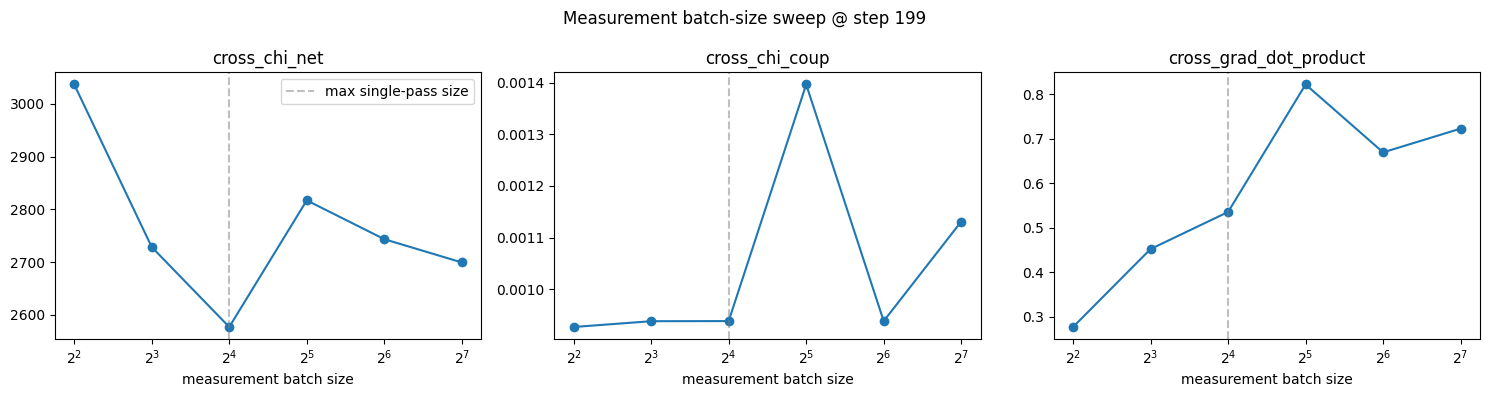

In [5]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

sweep_cols = [f"cross_chi_net@bs{S}" for S in MEASURE_BATCH_SIZES]
row = metrics.dropna(subset=sweep_cols).iloc[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["chi_net", "chi_coup", "grad_dot_product"]):
    ys = [row[f"cross_{metric}@bs{S}"] for S in MEASURE_BATCH_SIZES]
    ax.plot(MEASURE_BATCH_SIZES, ys, "o-")
    ax.axvline(MEASURE_MAX_SINGLE_PASS, color="gray", linestyle="--", alpha=0.5,
               label="max single-pass size")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("measurement batch size")
    ax.set_title(f"cross_{metric}")
axes[0].legend()

fig.suptitle(f"Measurement batch-size sweep @ step {int(row['step'])}")
plt.tight_layout()
plt.show()